## PCA and Text Analysis

This assignment involves processing real e-mails, some of which are scams. 

Fair warning: Some of these scam e-mails have offensive content. If you start reading the e-mail text or the token data, you might read something offensive. If that's a problem, feel free to e-mail me, and we can talk about it and discuss how to proceed with alternative tasks.

### Q1. 

**Tokens**: The individual words or symbols that create text data like emails. Natural Language Processing is primarily about analyzing the frequency and co-occurrence of tokens.

I aggregated all the emails into a single vector, and removed the punctuation and very common words (e.g. "the"). Run the below code chunk to open it, and use the Counter class to look at the most common words:

In [ ]:
import pickle
with open('data/all_tokens.pickle', 'rb') as file:
    all_tokens = pickle.load(file)
    
from collections import Counter
token_count = Counter(all_tokens)
token_freq = token_count.most_common()

Plot a histogram of the occurrences of tokens. 

What do you notice about the frequency of occurrence of different tokens? How does it look?

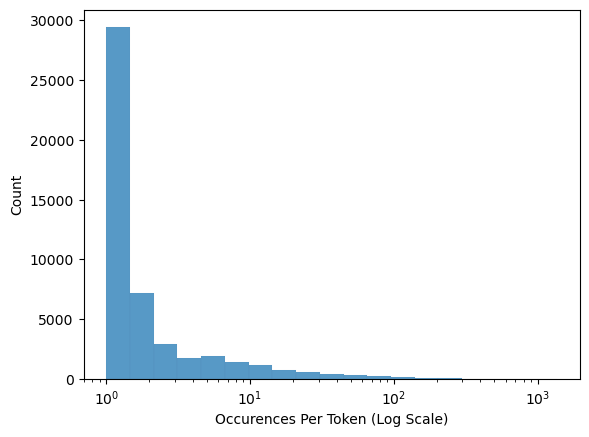

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

tokens = list(token_count.values())
bins = np.logspace(np.log10(1), np.log10(max(tokens)), num=20)

plt.figure()
sns.histplot(tokens, bins=bins)
plt.xscale('log')
plt.xlabel('Occurences Per Token (Log Scale)')
plt.show()

Based on the histogram, the data is extremely right skewed. This means that many of tokens do not appear very often, and there are a few tokens that appear a significant amount of times.

### Q2. 

Load `Phishing_clean.parquet`. This is the text from the e-mails broken into the most common 2,711 tokens and one-hot-encoded as features/covariates. So each row is an e-mail, the `Email Type` takes the value 1 if it's a scam and 0 otherwise, and every other column is a word or symbol that occurs in at least 15 e-mails.

1. Perform an 80/20 train-test split of the data.
2. Run a regression of $y$ on the one-hot-encoded emails. What is the $R^2$ on the test set? On the training set?
3. What words have the largest coefficients in absolute value and most strongly influence predictions? 

In [38]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

data = pd.read_parquet("./data/Phishing_clean.parquet")

In [39]:
# Question 2.1
X = data.drop(columns=['Email Type'])
y = data['Email Type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)

In [40]:
# Question 2.2
regression = LinearRegression()
regression.fit(X_train, y_train)

r2_train = regression.score(X_train, y_train)
r2_test = regression.score(X_test, y_test)

print(r2_train)
print(r2_test)

0.7687875341139676
0.6559239847466916


The R^2 on the training set is 0.769, and the R^2 on the test set is 0.656.

In [41]:
# Question 2.3
factors = X_train.columns
coefs = regression.coef_
abs_coefs = np.abs(coefs)

df = pd.DataFrame({
    'factor': factors,
    'coefficient': coefs,
    'absolute value': abs_coefs
})

largest = df.sort_values('absolute value', ascending=False)
largest.head(10)

,factor,coefficient,absolute value
1245,{text-decoration:,1.069928,1.069928
1504,background-image:,-0.896583,0.896583
1835,none;,-0.835839,0.835839
740,localized,0.763722,0.763722
2299,{color:,-0.680250,0.680250
2362,thermal,0.652498,0.652498
906,aging,0.650395,0.650395
1406,"helvetica,",0.626287,0.626287
818,cnet,-0.535749,0.535749
2202,group:,0.526756,0.526756


The words with the highest absolute value coefficients and most strongly influence predictions are text-decoration, background-image, none, and localized. These all have absolute value coefficients of above 0.7. 

### Q3. 

Take the matrix of one-hot-encoded tokens (the data, less the outcome variable, `Email Type`) and perform a principal components analysis decomposition with two components. Plot the first two principal components in a scatter plot, and hue the points by whether they are a phishing scam or not. Do you notice any patterns?

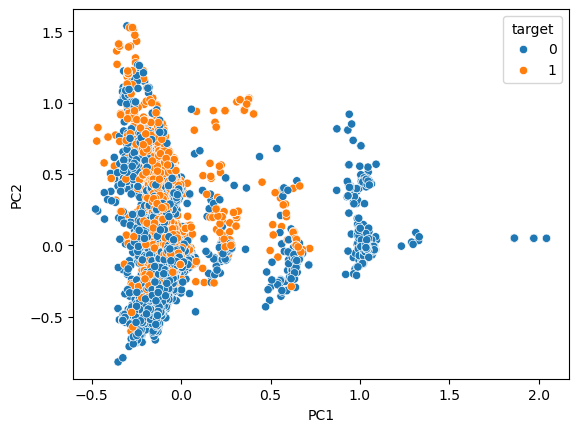

In [43]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
Z = pca.fit_transform(X)

pca_df = pd.DataFrame(Z, columns=['PC1', 'PC2'])
pca_df["target"] = y.values

plt.figure()
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='target')
plt.show()

Based on the scatterplot, we can see that there is a lot of overlap on the left side of the plot. This indicates that the PCA with the first two components does not do a great job at separating phishing emails vs. non-phishing emails. There is some separations of the points based on the target variable, but nothing that can lead to accurate classification.

### Q4.

Run a linear regression of $y$ on the first 2,610 principal components of $X$. What is the $R^2$ on the training and test sets? (I used cross validation to determine that 2,610 was approximately optimal, but not all 2,711 components.)

How does this performance compare to the linear regression?

In [45]:
pca_q4 = PCA(n_components=2610)
X_train_pca = pca_q4.fit_transform(X_train)
X_test_pca = pca_q4.transform(X_test)

regression_pca = LinearRegression()
regression_pca.fit(X_train_pca, y_train)

r2_train_pca = regression_pca.score(X_train_pca, y_train)
r2_test_pca = regression_pca.score(X_test_pca, y_test)

print(r2_train_pca)
print(r2_test_pca)

0.7678719293227679
0.6584780718049494


Based on the linear regression with 2,610 principal components of X, the R^2 on the training set is 0.768 and the R^2 on the test set is 0.658. This is about the same as the performance of the linear regression model from Q2.

### Q5.

Explain briefly in your own words what the advantage is in using the principal components to run this high-dimensional regression, rather than the original data.

The advantage of using the principal components to run this high-dimensional regression (rather than the original data), is that the PCA model is able to improve model stability and interpretability without diminishing the predictive power. This is because the original model typically will involve multicollinearity, leading to overfitting (making the model less stable and interpretable). PCA reduces the dimensionality while still capturing the majority of the variance in the data.